# Experiment 004 — Model Selection

**Goal:** Compare 5 model architectures using the exp_003 feature set and Random Undersampling. Identify the best architecture before hyperparameter tuning in exp_005.

**Feature set:** exp_003 (LogFare, AgeGroup, FamilySize, IsAlone, Pclass×Fare, FarePerPerson, title grouping)
**Imbalance method:** Random Undersampling (consistent across all models so architecture is the only variable)

**Models compared:**
1. Random Forest — exp_003 baseline reference
2. Logistic Regression — linear baseline; tests whether tree complexity is needed
3. SVM — non-linear kernel; strong on small datasets
4. XGBoost — gradient boosting; level-wise growth
5. CatBoost — gradient boosting; ordered boosting; robust to overfitting

**Selection criterion:** F1 (Survived) — same as exp_002/003

## 1. Imports

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
%matplotlib inline

## 2. Load, Preprocess & Feature Engineering (identical to exp_003)

In [10]:
df = pd.read_csv('../../data/raw/train.csv')
df = df.drop(columns=['PassengerId'])

df['Name_title']        = df['Name'].str.extract(r',\s*([^.]+)\.')
df['Cabin_deck']        = df['Cabin'].str[0]
df = df.drop(columns=['Name', 'Ticket', 'Cabin'])

X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train.copy()
X_test  = X_test.copy()

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 712 | Test: 179


In [11]:
# Impute (fit on train only)
age_median    = X_train['Age'].median()
embarked_mode = X_train['Embarked'].mode()[0]

for df_ in [X_train, X_test]:
    df_['Age']        = df_['Age'].fillna(age_median)
    df_['Embarked']   = df_['Embarked'].fillna(embarked_mode)
    df_['Cabin_deck'] = df_['Cabin_deck'].fillna('Unknown')

# Title grouping
title_map     = {'Mlle': 'Miss', 'Mme': 'Mrs', 'Ms': 'Miss'}
common_titles = {'Mr', 'Mrs', 'Miss', 'Master'}
for df_ in [X_train, X_test]:
    df_['Name_title'] = df_['Name_title'].replace(title_map)
    df_['Name_title'] = df_['Name_title'].apply(lambda t: t if t in common_titles else 'Rare')

# Family features
for df_ in [X_train, X_test]:
    df_['FamilySize'] = df_['SibSp'] + df_['Parch'] + 1
    df_['IsAlone']    = (df_['FamilySize'] == 1).astype(int)

# Log transform
for df_ in [X_train, X_test]:
    df_['LogFare'] = np.log1p(df_['Fare'])

# Age binning
bins, labels = [0, 16, 60, np.inf], ['Child', 'Adult', 'Senior']
for df_ in [X_train, X_test]:
    df_['AgeGroup'] = pd.cut(df_['Age'], bins=bins, labels=labels)

# Interaction & ratio
for df_ in [X_train, X_test]:
    df_['Pclass_x_Fare'] = df_['Pclass'] * df_['Fare']
    df_['FarePerPerson'] = df_['Fare'] / df_['FamilySize']

# Drop weak feature
for df_ in [X_train, X_test]:
    df_.drop(columns=['SibSp', 'Parch'], inplace=True, errors='ignore')

print('Feature engineering complete.')
print(f'Columns: {list(X_train.columns)}')

Feature engineering complete.
Columns: ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Name_title', 'Cabin_deck', 'FamilySize', 'IsAlone', 'LogFare', 'AgeGroup', 'Pclass_x_Fare', 'FarePerPerson']


In [12]:
# Encode
encode_cols = ['Sex', 'Embarked', 'Name_title', 'Cabin_deck', 'AgeGroup']
X_train = pd.get_dummies(X_train, columns=encode_cols, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=encode_cols, drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Scale (needed for LR and SVM; harmless for tree models)
num_scale_cols = ['Age', 'Fare', 'FamilySize', 'LogFare', 'Pclass_x_Fare', 'FarePerPerson']
scaler = StandardScaler()
X_train[num_scale_cols] = scaler.fit_transform(X_train[num_scale_cols])
X_test[num_scale_cols]  = scaler.transform(X_test[num_scale_cols])

print(f'Final feature count: {X_train.shape[1]}')
print(f'Total nulls: {X_train.isnull().sum().sum()}')

Final feature count: 25
Total nulls: 0


## 3. Model Comparison

In [13]:
models = {
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM':                 SVC(probability=True, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='logloss', verbosity=0),
    'CatBoost':            CatBoostClassifier(iterations=100, random_state=42, verbose=0),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rus = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

results     = []
predictions = {}   # store per-model predictions for error analysis

for name, clf in models.items():
    clf.fit(X_train_res, y_train_res)
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]
    report = classification_report(y_test, y_pred, output_dict=True)

    predictions[name] = y_pred   # save for error analysis

    cv_pipe = ImbPipeline([
        ('sampler', RandomUnderSampler(random_state=42)),
        ('clf',     clf.__class__(**clf.get_params())),
    ])
    cv_auc = cross_val_score(cv_pipe, X_train, y_train, cv=skf, scoring='roc_auc').mean()

    results.append({
        'Model':                name,
        'Hold-out AUC':         round(roc_auc_score(y_test, y_prob), 4),
        'CV AUC':               round(cv_auc, 4),
        'Precision (Survived)': round(report['1']['precision'], 3),
        'Recall (Survived)':    round(report['1']['recall'], 3),
        'F1 (Survived)':        round(report['1']['f1-score'], 3),
        'Accuracy':             round(report['accuracy'], 3),
    })
    print(f'{name} done.')

results_df = pd.DataFrame(results).set_index('Model')
results_df

Random Forest done.
Logistic Regression done.
SVM done.
XGBoost done.
CatBoost done.


,Hold-out AUC,CV AUC,Precision (Survived),Recall (Survived),F1 (Survived),Accuracy
Model,,,,,,
Random Forest,0.8232,0.8771,0.643,0.783,0.706,0.749
Logistic Regression,0.8503,0.8723,0.724,0.797,0.759,0.804
SVM,0.8437,0.8681,0.695,0.826,0.755,0.793
XGBoost,0.8255,0.8838,0.690,0.841,0.758,0.793
CatBoost,0.8506,0.8909,0.757,0.812,0.783,0.827


## 4. Visualise Comparison

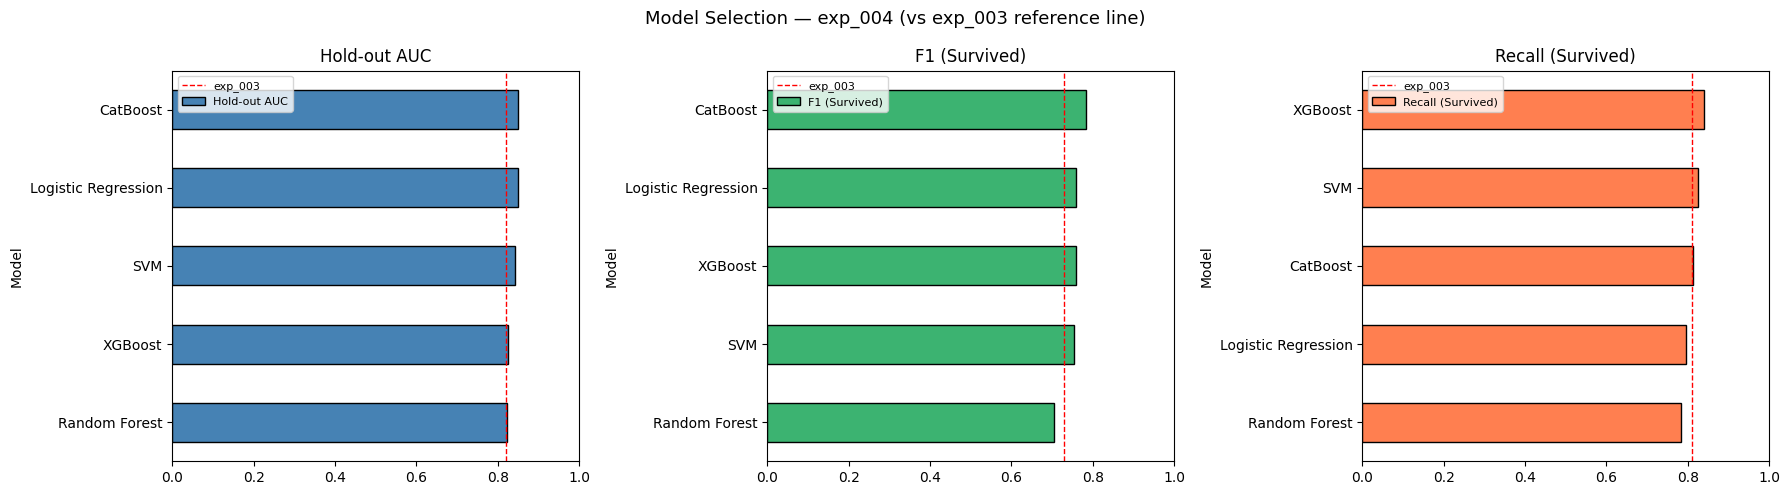

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Hold-out AUC', 'F1 (Survived)', 'Recall (Survived)']
colors  = ['steelblue', 'mediumseagreen', 'coral']

for ax, metric, color in zip(axes, metrics, colors):
    results_df[metric].sort_values().plot(kind='barh', ax=ax, color=color, edgecolor='black')
    ax.set_title(metric)
    ax.set_xlim(0, 1)
    # Reference line: exp_003 score
    ref = {'Hold-out AUC': 0.8216, 'F1 (Survived)': 0.73, 'Recall (Survived)': 0.81}
    ax.axvline(ref[metric], color='red', linestyle='--', linewidth=1, label='exp_003')
    ax.legend(fontsize=8)

plt.suptitle('Model Selection — exp_004 (vs exp_003 reference line)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Best Model — Detailed Report

Best model by F1 (Survived): CatBoost

ROC-AUC: 0.8506

              precision    recall  f1-score   support

Not Survived       0.88      0.84      0.86       110
    Survived       0.76      0.81      0.78        69

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



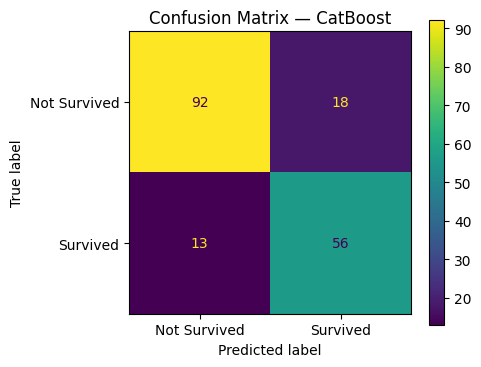

In [15]:
best_model_name = results_df['F1 (Survived)'].idxmax()
print(f'Best model by F1 (Survived): {best_model_name}')

best_clf = models[best_model_name]
best_clf.fit(X_train_res, y_train_res)

y_pred = best_clf.predict(X_test)
y_prob = best_clf.predict_proba(X_test)[:, 1]

print(f'\nROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(best_clf, X_test, y_test,
                                      display_labels=['Not Survived', 'Survived'], ax=ax)
plt.title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.show()

## 6. Error Analysis

In [ ]:
# Build error sets — indices of misclassified passengers per model
y_test_arr = y_test.values
test_idx   = np.arange(len(y_test_arr))

error_sets = {
    name: set(test_idx[preds != y_test_arr])
    for name, preds in predictions.items()
}

print('Error counts per model:')
for name, errs in error_sets.items():
    print(f'  {name}: {len(errs)} errors ({len(errs)/len(y_test_arr)*100:.1f}%)')

Error counts per model:
  Random Forest: 45 errors (25.1%)
  Logistic Regression: 35 errors (19.6%)
  SVM: 37 errors (20.7%)
  XGBoost: 37 errors (20.7%)
  CatBoost: 31 errors (17.3%)


Pairwise error overlap (% of row model errors also made by column model):
                     Random Forest  Logistic Regression    SVM  XGBoost  \
Random Forest                100.0                 60.0   66.7     66.7   
Logistic Regression           77.1                100.0   88.6     57.1   
SVM                           81.1                 83.8  100.0     62.2   
XGBoost                       81.1                 54.1   62.2    100.0   
CatBoost                      87.1                 87.1   90.3     64.5   

                     CatBoost  
Random Forest            60.0  
Logistic Regression      77.1  
SVM                      75.7  
XGBoost                  54.1  
CatBoost                100.0  


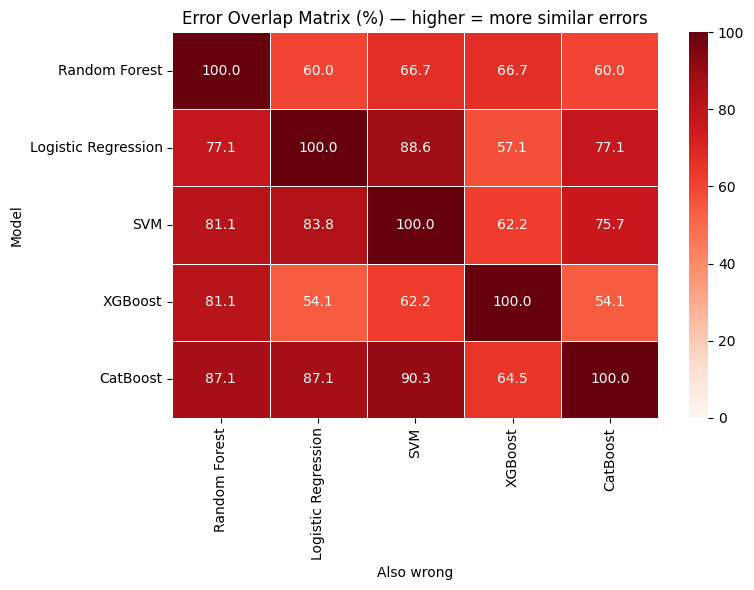

In [17]:
# Pairwise error overlap matrix
# Each cell = % of model A's errors that are ALSO made by model B
# High overlap (>70%) → models fail on same passengers → ensembling unlikely to help
model_names = list(error_sets.keys())
overlap = pd.DataFrame(index=model_names, columns=model_names, dtype=float)

for a in model_names:
    for b in model_names:
        if len(error_sets[a]) == 0:
            overlap.loc[a, b] = 0.0
        else:
            overlap.loc[a, b] = round(
                len(error_sets[a] & error_sets[b]) / len(error_sets[a]) * 100, 1
            )

print('Pairwise error overlap (% of row model errors also made by column model):')
print(overlap)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(overlap.astype(float), annot=True, fmt='.1f', cmap='Reds',
            vmin=0, vmax=100, linewidths=0.5, ax=ax)
ax.set_title('Error Overlap Matrix (%) — higher = more similar errors')
ax.set_xlabel('Also wrong')
ax.set_ylabel('Model')
plt.tight_layout()
plt.show()

In [18]:
# Hard cases — passengers ALL models get wrong
all_wrong = set.intersection(*error_sets.values())
any_wrong = set.union(*error_sets.values())

print(f'Errors made by ALL models:  {len(all_wrong)} passengers ({len(all_wrong)/len(y_test_arr)*100:.1f}%)')
print(f'Errors made by ANY model:   {len(any_wrong)} passengers ({len(any_wrong)/len(y_test_arr)*100:.1f}%)')
print(f'Errors unique to 1 model:   {sum(1 for i in any_wrong if sum(i in e for e in error_sets.values()) == 1)}')

# Profile hard cases vs correctly-classified passengers
# Use raw (unscaled) test features for interpretability
X_test_raw = X_test.copy()
X_test_raw['y_true']    = y_test_arr
X_test_raw['all_wrong'] = X_test_raw.index.isin(
    [y_test.index[i] for i in all_wrong]
)

print('\nFeature means — hard cases (all models wrong) vs rest:')
num_features = ['Age', 'Fare', 'FamilySize', 'Pclass_x_Fare', 'FarePerPerson', 'LogFare']
available = [c for c in num_features if c in X_test_raw.columns]
print(X_test_raw.groupby('all_wrong')[available].mean().round(3))

Errors made by ALL models:  15 passengers (8.4%)
Errors made by ANY model:   62 passengers (34.6%)
Errors unique to 1 model:   19

Feature means — hard cases (all models wrong) vs rest:
             Age   Fare  FamilySize  Pclass_x_Fare  FarePerPerson  LogFare
all_wrong                                                                 
False     -0.058  0.046       0.089          0.058         -0.056    0.082
True       0.203 -0.027      -0.178         -0.242         -0.141   -0.203


In [19]:
# Ensembling decision rule:
# - Overlap > 70% across most pairs → hard cases are shared → ensembling won't help
# - Overlap < 50% across diverse pairs → models make different errors → ensembling worthwhile

avg_off_diag = overlap.values[~np.eye(len(model_names), dtype=bool)].mean()
print(f'Average pairwise error overlap (off-diagonal): {avg_off_diag:.1f}%')
print()
if avg_off_diag >= 70:
    print('Conclusion: HIGH overlap — models fail on the same passengers.')
    print('Ensembling is unlikely to improve results meaningfully.')
    print('Recommendation: Proceed to exp_005 (hyperparameter tuning of CatBoost).')
elif avg_off_diag >= 50:
    print('Conclusion: MODERATE overlap — some diversity between models.')
    print('Ensembling may give a small lift. Consider soft voting after tuning in exp_005.')
else:
    print('Conclusion: LOW overlap — models make different errors.')
    print('Ensembling is likely worthwhile. Consider stacking or soft voting after exp_005.')

Average pairwise error overlap (off-diagonal): 71.8%

Conclusion: HIGH overlap — models fail on the same passengers.
Ensembling is unlikely to improve results meaningfully.
Recommendation: Proceed to exp_005 (hyperparameter tuning of CatBoost).


## 6. Comparison vs All Experiments

In [20]:
# Fill in after running
summary = pd.DataFrame([
    {'Experiment': 'exp_001 Baseline RF',         'CV AUC': 0.8741, 'Hold-out AUC': 0.8282, 'Precision (Survived)': 0.75, 'Recall (Survived)': 0.68, 'F1 (Survived)': 0.71, 'Accuracy': 0.79},
    {'Experiment': 'exp_002 Undersample RF',       'CV AUC': 0.8724, 'Hold-out AUC': 0.8237, 'Precision (Survived)': 0.63, 'Recall (Survived)': 0.77, 'F1 (Survived)': 0.69, 'Accuracy': 0.74},
    {'Experiment': 'exp_003 FE + Undersample RF',  'CV AUC': 0.8727, 'Hold-out AUC': 0.8216, 'Precision (Survived)': 0.66, 'Recall (Survived)': 0.81, 'F1 (Survived)': 0.73, 'Accuracy': 0.77},
]).set_index('Experiment')

# Append best model from this experiment
best_row = results_df.loc[[best_model_name]].rename(index={best_model_name: f'exp_004 {best_model_name}'})
summary = pd.concat([summary, best_row[summary.columns]])
summary

,CV AUC,Hold-out AUC,Precision (Survived),Recall (Survived),F1 (Survived),Accuracy
exp_001 Baseline RF,0.8741,0.8282,0.750,0.680,0.710,0.790
exp_002 Undersample RF,0.8724,0.8237,0.630,0.770,0.690,0.740
exp_003 FE + Undersample RF,0.8727,0.8216,0.660,0.810,0.730,0.770
exp_004 CatBoost,0.8909,0.8506,0.757,0.812,0.783,0.827
